# SLM vs MRCD on 120/80 Split

This notebook:
1. Loads preprocessed data
2. Builds 120/80 split from first 200 samples by time
3. Fine-tunes SLM on train (120), evaluates on test (80)
4. Runs MRCD round-by-round in a single logic cell (no pipeline wrapper call)
5. Exports logs and compares SLM-only vs MRCD

In [1]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

# Replace "YOUR_HF_TOKEN" with your actual token
login(token=user_secrets.get_secret("HF_TOKEN"))
print("login")

login


In [ ]:
import os

GITHUB_REPO = "https://github.com/Chinh-de/Fake-news-detection.git"
REPO_NAME = "Fake-news-detection"
BRANCH = "MRCD-FTT"          # tên nhánh bạn muốn clone

if os.path.exists(REPO_NAME):
    # Xoá thư mục cũ nếu tồn tại để tránh xung đột (hoặc có thể cd vào và git pull)
    !rm -rf {REPO_NAME}

!git clone -b {BRANCH} {GITHUB_REPO}
%cd {REPO_NAME}

Cloning into 'Fake-news-detection'...
remote: Enumerating objects: 141, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 141 (delta 31), reused 132 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (141/141), 879.51 KiB | 7.92 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/kaggle/working/Fake-news-detection


In [3]:
!pip install -r requirements.txt --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 58.5 MB/s eta 0:00:00


In [4]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

ROOT_DIR = Path('..').resolve()
REPO_DIR = ROOT_DIR / 'Fake-news-detection'
if str(REPO_DIR) not in sys.path:
    sys.path.append(str(REPO_DIR))

from src.utils import preprocess_text, log_prediction_to_csv, log_round_trace_to_csv
from src.slm.model import IntegratedSLM
from src.pipeline.evidence import prefetch_query_context, build_evidence_bundle, assess_with_llm
from src.pipeline.selection import split_clean_noisy, finalize_remaining_noisy_with_slm
from src.retrieval.demo_retrieval import load_news_corpus
from src.llm.handler import get_llm
from src.config import (
    NUM_LOOP, CONFIDENCE_THRESHOLD, TOP_K_DEMOS, FACT_TOP_K,
    ENABLE_SLM_FINETUNE, SLM_FINETUNE_EPOCHS, SLM_FINETUNE_BATCH_SIZE,
    SLM_FINETUNE_LR, SLM_FINETUNE_WEIGHT_DECAY, SLM_FINETUNE_MIN_SAMPLES,
)

# Log lưu ngoài repo
LOG_DIR = ROOT_DIR / 'log'
LOG_DIR.mkdir(parents=True, exist_ok=True)

SLM_PRED_CSV = LOG_DIR / 'slm_test_predictions.csv'
MRCD_PRED_CSV = LOG_DIR / 'mrcd_final_predictions.csv'
MRCD_ROUND_METRICS_CSV = LOG_DIR / 'mrcd_round_metrics.csv'
COMPARISON_CSV = LOG_DIR / 'slm_vs_mrcd_metrics.csv'
TRACE_CSV_PATH = LOG_DIR / 'mrcd_trace.csv'
RESULTS_CSV_PATH = LOG_DIR / 'mrcd_results.csv'

for p in [SLM_PRED_CSV, MRCD_PRED_CSV, MRCD_ROUND_METRICS_CSV, COMPARISON_CSV, TRACE_CSV_PATH, RESULTS_CSV_PATH]:
    if p.exists():
        p.unlink()

print(f'Root: {ROOT_DIR}')
print(f'Repo dir: {REPO_DIR}')
print(f'Log dir (outside repo): {LOG_DIR}')

Root: /kaggle/working
Repo dir: /kaggle/working/Fake-news-detection
Log dir (outside repo): /kaggle/working/log


In [5]:
def summarize_round_stats(event_states, d_clean, round_id):
    round_states = [s for s in event_states if int(s.get('round', 0)) == round_id]
    clean_added_states = [s for s in d_clean if int(s.get('round', 0)) == round_id]
    clean_cumulative_states = list(d_clean)

    def accuracy_from_states(states, pred_key):
        pairs = [
            (int(s['ground_truth']), int(s[pred_key]))
            for s in states
            if s.get('ground_truth') is not None and s.get(pred_key) is not None
        ]
        if not pairs:
            return None, 0, 0
        correct = sum(1 for y_true, y_pred in pairs if y_true == y_pred)
        return correct / len(pairs), len(pairs), correct

    dclean_added_acc, dclean_added_n, dclean_added_correct = accuracy_from_states(
        clean_added_states, 'label_slm'
    )
    dclean_total_acc, dclean_total_n, dclean_total_correct = accuracy_from_states(
        clean_cumulative_states, 'label_slm'
    )
    slm_round_acc, slm_round_n, slm_round_correct = accuracy_from_states(
        round_states, 'label_slm'
    )
    llm_round_acc, llm_round_n, llm_round_correct = accuracy_from_states(
        round_states, 'label_llm'
    )

    return {
        'round': round_id,
        'round_samples': len(round_states),
        'dclean_added_count': len(clean_added_states),
        'dclean_total_count': len(clean_cumulative_states),
        'dclean_added_accuracy': dclean_added_acc,
        'dclean_total_accuracy': dclean_total_acc,
        'dclean_added_correct': dclean_added_correct,
        'dclean_total_correct': dclean_total_correct,
        'slm_round_accuracy': slm_round_acc,
        'llm_round_accuracy': llm_round_acc,
        'slm_round_correct': slm_round_correct,
        'llm_round_correct': llm_round_correct,
        'slm_round_count': slm_round_n,
        'llm_round_count': llm_round_n,
    }

### 1. Chuẩn bị dữ liệu và chia tập 120/80
Phần này nạp dữ liệu đã tiền xử lý, sắp theo thời gian và chia train/test theo mốc 120/80.

In [6]:
# DATA_PATH = REPO_DIR / 'dataset' / 'twitter15_16_preprocessed.csv'

# df = pd.read_csv(DATA_PATH)
# df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
# df['text'] = df['text'].astype(str).apply(preprocess_text)
# df = df.sort_values('timestamp').reset_index(drop=True)

# df_200 = df.head(2000).copy()
# df_200['label_bin'] = df_200['label'].astype(str).str.lower().map(lambda x: 0 if x in ['true', 'non-rumor'] else 1)
# df_200['split'] = ['train'] * 1800 + ['test'] * 200
# # df_200 = df.head(20).copy()
# # df_200['label_bin'] = df_200['label'].astype(str).str.lower().map(lambda x: 0 if x in ['true', 'non-rumor'] else 1)
# # df_200['split'] = ['train'] * 12 + ['test'] * 8

# train_df = df_200[df_200['split'] == 'train'].copy()
# test_df = df_200[df_200['split'] == 'test'].copy()

# print(f'Total used: {len(df_200)} | Train: {len(train_df)} | Test: {len(test_df)}')
# print('Train labels:', train_df['label_bin'].value_counts().to_dict())
# print('Test labels:', test_df['label_bin'].value_counts().to_dict())




import pandas as pd

# Hàm chuyển tweet_id -> datetime (giải mã Snowflake)
def tweet_id_to_datetime(tweet_id):
    TWEPOCH = 1288834974657  # Twitter epoch (ms)
    timestamp_ms = (tweet_id >> 22) + TWEPOCH
    return pd.to_datetime(timestamp_ms, unit='ms')

# Đường dẫn file (điều chỉnh nếu cần)
TRAIN_PATH = "/kaggle/input/datasets/chinhde/twitter15-16/train.csv"
TEST_PATH  = "/kaggle/input/datasets/chinhde/twitter15-16/test.csv"

# Đọc dữ liệu, đổi tên cột tweet_id thành id
train_df = pd.read_csv(TRAIN_PATH, usecols=['tweet_id', 'text', 'label'])
test_df  = pd.read_csv(TEST_PATH,  usecols=['tweet_id', 'text', 'label'])

# Đổi tên cột
train_df = train_df.rename(columns={'tweet_id': 'id'})
test_df = test_df.rename(columns={'tweet_id': 'id'})

# Tạo timestamp từ id
train_df['timestamp'] = train_df['id'].apply(tweet_id_to_datetime)
test_df['timestamp']  = test_df['id'].apply(tweet_id_to_datetime)


train_df['text'] = train_df['text'].astype(str).apply(preprocess_text)
test_df['text']  = test_df['text'].astype(str).apply(preprocess_text)

# Sắp xếp theo timestamp
train_df = train_df.sort_values('timestamp').reset_index(drop=True)
test_df  = test_df.sort_values('timestamp').reset_index(drop=True)

# Tạo nhãn nhị phân: 0 = true/non-rumor, 1 = còn lại
def to_binary(label):
    return 0 if str(label).lower() in ['true', 'non-rumor'] else 1

train_df['label_bin'] = train_df['label'].apply(to_binary)
test_df['label_bin']  = test_df['label'].apply(to_binary)

# Gán nhãn split để sau này vẽ chung
train_df['split'] = 'train'
test_df['split']  = 'test'

# Gộp và sắp xếp theo timestamp
combined = pd.concat([train_df, test_df], ignore_index=True)
combined = combined.sort_values('timestamp').reset_index(drop=True)

print(f'Train size: {len(train_df)} | Test size: {len(test_df)}')
print('Train labels:', train_df['label_bin'].value_counts().to_dict())
print('Test labels:', test_df['label_bin'].value_counts().to_dict())

Train size: 1711 | Test size: 428
Train labels: {0: 902, 1: 809}
Test labels: {0: 256, 1: 172}


### 2. Trực quan phân phối theo thời gian
Vẽ timeline 200 mẫu đầu và biểu đồ phân phối nhãn cho train/test.

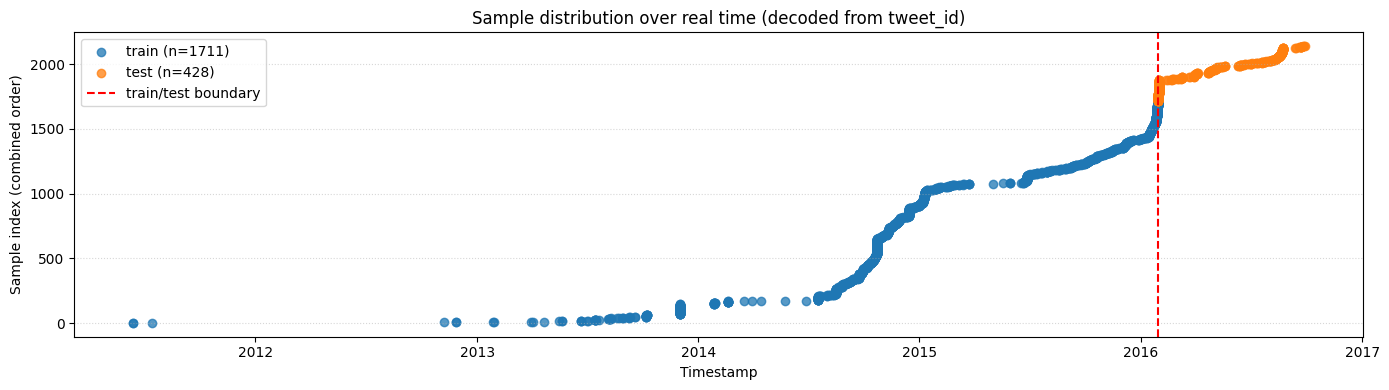

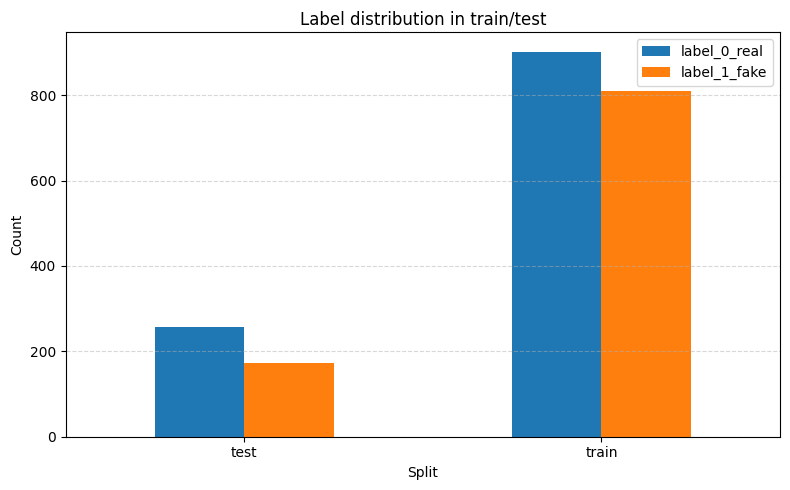

In [7]:
# # Time split and distribution
# plt.figure(figsize=(14, 4))
# for split, color in [('train', 'tab:blue'), ('test', 'tab:orange')]:
#     subset = df_200[df_200['split'] == split]
#     plt.scatter(subset['timestamp'], subset.index + 1, label=f'{split} (n={len(subset)})', alpha=0.75, color=color)

# cut_time = df_200.iloc[1999]['timestamp']
# plt.axvline(cut_time, color='red', linestyle='--', label='cut at 120')
# plt.title('First 200 samples over time with 120/80 split')
# plt.xlabel('Timestamp')
# plt.ylabel('Sample index (1..200)')
# plt.grid(axis='y', linestyle=':', alpha=0.5)
# plt.legend()
# plt.tight_layout()
# plt.show()

# dist = df_200.groupby(['split', 'label_bin']).size().reset_index(name='count')
# dist_pivot = dist.pivot(index='split', columns='label_bin', values='count').fillna(0)
# dist_pivot.columns = ['label_0_real', 'label_1_fake']
# dist_pivot.plot(kind='bar', figsize=(8, 5))
# plt.title('Label distribution in train/test')
# plt.xlabel('Split')
# plt.ylabel('Count')
# plt.xticks(rotation=0)
# plt.grid(axis='y', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()



import matplotlib.pyplot as plt

# --- Biểu đồ 1: Phân bố mẫu theo thời gian thực ---
plt.figure(figsize=(14, 4))
for split, color in [('train', 'tab:blue'), ('test', 'tab:orange')]:
    subset = combined[combined['split'] == split]
    plt.scatter(subset['timestamp'], subset.index + 1,
                label=f'{split} (n={len(subset)})', alpha=0.75, color=color)

# Đường phân cách giữa train và test (thời điểm cuối của train)
cut_time = train_df['timestamp'].max()
plt.axvline(cut_time, color='red', linestyle='--', label='train/test boundary')

plt.title('Sample distribution over real time (decoded from tweet_id)')
plt.xlabel('Timestamp')
plt.ylabel('Sample index (combined order)')
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# --- Biểu đồ 2: Phân bố nhãn trên train/test ---
dist = combined.groupby(['split', 'label_bin']).size().reset_index(name='count')
dist_pivot = dist.pivot(index='split', columns='label_bin', values='count').fillna(0)
dist_pivot.columns = ['label_0_real', 'label_1_fake']

dist_pivot.plot(kind='bar', figsize=(8, 5))
plt.title('Label distribution in train/test')
plt.xlabel('Split')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 3. Fine-tune SLM và đánh giá trên tập test
Huấn luyện SLM trên train, dự đoán test và lưu kết quả SLM-only.

Loading SLM from Hugging Face model id: roberta-base


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

SLM loaded (HF backend) on cuda


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tune stats: {'trained': True, 'samples': 1711, 'epochs': 15, 'batch_size': 32, 'lr': 0.001, 'weight_decay': 0.0001, 'train_loss_history': [0.6942458086543613, 0.647609430330771, 0.59906148744954, 0.542916903341258, 0.517797178140393, 0.4977075556914012, 0.4919320720213431, 0.47074140497931727, 0.4785211566421721, 0.4646542298573035, 0.4609380000167423, 0.46214752120000346, 0.4456091622511546, 0.4515024627800341, 0.4426414284993101], 'save_path': '/kaggle/working/Fake-news-detection/dataset/slm_120_80'}
Loading SLM from local path: /kaggle/working/Fake-news-detection/dataset/slm_120_80


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

SLM loaded (HF backend) on cuda


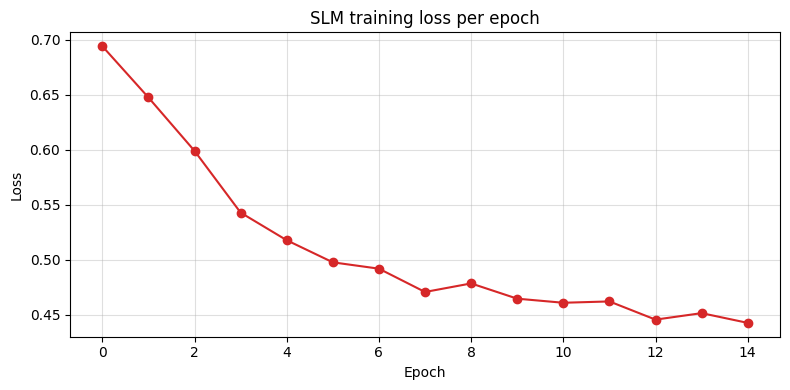

SLM-only Test Accuracy: 0.6425
SLM-only Precision: 0.5508 | Recall: 0.5988 | F1: 0.5738
              precision    recall  f1-score   support

     real(0)     0.7137    0.6719    0.6922       256
     fake(1)     0.5508    0.5988    0.5738       172

    accuracy                         0.6425       428
   macro avg     0.6322    0.6354    0.6330       428
weighted avg     0.6482    0.6425    0.6446       428



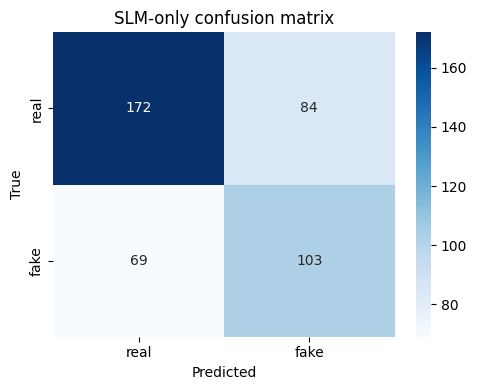

Saved: /kaggle/working/log/slm_test_predictions.csv


In [ ]:
# Fine-tune SLM from Hugging Face initialization, then evaluate on test
train_texts = train_df['text'].tolist()
train_labels = train_df['label_bin'].astype(int).tolist()
test_texts = test_df['text'].tolist()
test_labels = test_df['label_bin'].astype(int).tolist()

SLM_SAVE_DIR = REPO_DIR / 'dataset' / 'slm_120_80'
SLM_SAVE_DIR.mkdir(parents=True, exist_ok=True)

# HF initialization for fine-tuning (using EANN with BERT)
slm = IntegratedSLM()  # Uses default BERT from config
ft_stats = slm.finetune(
    train_texts=train_texts,
    train_labels=train_labels,
    model_init='bert-base-uncased',
    epochs=15,
    batch_size=32,
    lr=1e-3,
    weight_decay=1e-4,
    warmup_ratio=0.1,
    max_grad_norm=1.0,
    save_path=None,  # Skip saving for Kaggle compatibility
)

print('Fine-tune stats:', ft_stats)

# Reload the fine-tuned HF checkpoint for downstream use (skip for Kaggle)
# slm = IntegratedSLM(model_path=str(SLM_SAVE_DIR), backend='hf')

In [9]:
import gc
import torch

# 1. Đo lường trước khi dọn
stats_before = []
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        stats_before.append({
            "alloc": torch.cuda.memory_allocated(i) / (1024 ** 2),
            "res": torch.cuda.memory_reserved(i) / (1024 ** 2)
        })

# 2. Giải phóng biến model và dọn rác System RAM
if 'slm' in globals():
    del slm
gc.collect()

# 3. Dọn dẹp VRAM trên TẤT CẢ GPU
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        torch.cuda.set_device(i)
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except:
            pass
    
    # Trả về device 0 để tránh lỗi chạy các cell sau
    torch.cuda.set_device(0)

    # 4. In báo cáo so sánh
    print(f"--- VRAM ({torch.cuda.device_count()} GPU) ---")
    for i in range(torch.cuda.device_count()):
        after_alloc = torch.cuda.memory_allocated(i) / (1024 ** 2)
        after_reserved = torch.cuda.memory_reserved(i) / (1024 ** 2)
        print(f"GPU {i}:")
        print(f"  Allocated: {stats_before[i]['alloc']:.1f}MB -> {after_alloc:.1f}MB")
        print(f"  Reserved:  {stats_before[i]['res']:.1f}MB -> {after_reserved:.1f}MB")
else:
    print('Không có CUDA, bỏ qua bước giải phóng VRAM.')

--- VRAM (2 GPU) ---
GPU 0:
  Allocated: 498.1MB -> 17.2MB
  Reserved:  1044.0MB -> 26.0MB
GPU 1:
  Allocated: 0.0MB -> 0.0MB
  Reserved:  0.0MB -> 0.0MB


### 4. MRCD nhiều vòng (Round-based)


#### 4.1 MRCD - Khởi tạo + Bootstrap + Round 1

In [10]:
from tqdm.auto import tqdm


In [ ]:
# Load the fine-tuned Hugging Face SLM checkpoint for MRCD inference (use same instance for Kaggle)
slm_mrcd = slm  # Reuse the fine-tuned SLM instance

Loading SLM from local path: /kaggle/working/Fake-news-detection/dataset/slm_120_80


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

SLM loaded (HF backend) on cuda


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

 Loaded LLM: meta-llama/Meta-Llama-3-8B-Instruct
 Loaded 120000 documents from AG News.
Initialized MRCD with 428 events


In [12]:
# Bootstrap context (parallel I/O to speed up retrieval)
from concurrent.futures import ThreadPoolExecutor, as_completed

unique_texts = list(dict.fromkeys([s['text'] for s in event_states]))
context_map = {}

# I/O-bound workload (knowledge + news retrieval), so threads help.
max_workers = min(12, max(4, len(unique_texts))) if unique_texts else 4


def _fetch_one_context(text):
    return text, prefetch_query_context(
        text=text,
        demo_k=TOP_K_DEMOS,
        fact_top_k=FACT_TOP_K,
        reuse_knowledge_cache=True,
        knowledge_cache_local=knowledge_cache_local,
        knowledge_mode=mode,
        wiki_fetch_full=wiki_fetch_full,
    )


if unique_texts:
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(_fetch_one_context, text) for text in unique_texts]
        for future in tqdm(as_completed(futures), total=len(futures), desc='Bootstrap context (parallel)'):
            text, qctx = future.result()
            context_map[text] = qctx

for state in event_states:
    qctx = context_map.get(state['text'], {
        'knowledge_text': 'No info.',
        'bing_seed_news': [],
    })
    state['query_context'] = qctx
    state['knowledge'] = qctx.get('knowledge_text', 'No info.')

print(f'Bootstrap done: {len(unique_texts)} unique texts | workers={max_workers}')

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Bootstrap context (parallel):   0%|          | 0/412 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignore

Bootstrap done: 412 unique texts | workers=12


In [13]:
CONFIDENCE_THRESHOLD = 0.7

In [14]:
# Round 1
round_id = 1
for state in tqdm(event_states, desc='Round 1 - LLM assess'):
    demos, knowledge_k, retrieval_source = build_evidence_bundle(
        text=state['text'],
        static_corpus=static_corpus,
        clean_pool=d_clean,
        round_id=round_id,
        query_context=state['query_context'],
        demo_k=TOP_K_DEMOS,
    )
    assess = assess_with_llm(text=state['text'], demos=demos, knowledge_k=knowledge_k, llm=llm)
    state.update({
        'round': round_id,
        'label': assess['y_llm'],
        'label_llm': assess['y_llm'],
        'llm_raw': assess['llm_raw'],
        'llm_label_matched': assess['llm_label_matched'],
        'retrieval_source': retrieval_source,
        'knowledge': knowledge_k,
        'prompt': assess['prompt'],
    })

slm_batch = slm_mrcd.inference_batch([s['text'] for s in event_states], batch_size=32)
for state, res in tqdm(list(zip(event_states, slm_batch)), desc='Round 1 - merge/split', total=len(event_states)):
    pred, conf, _ = res
    state['label_slm'] = pred
    state['y_slm'] = pred
    state['conf_slm'] = conf

    log_round_trace_to_csv(
        round_id=round_id,
        event_id=state['event_id'],
        text=state['text'],
        y_slm=state['y_slm'],
        y_llm=state['label_llm'],
        ground_truth=state['ground_truth'],
        conf_slm=state['conf_slm'],
        prompt=state['prompt'],
        filepath=str(TRACE_CSV_PATH),
    )

    if split_clean_noisy(state, CONFIDENCE_THRESHOLD):
        state['status'] = 'clean'
        d_clean.append(state)
        log_prediction_to_csv(
            event_id=state['event_id'],
            text=state['text'],
            label=state['label'],
            conf=state['conf_slm'],
            round_id=round_id,
            status=state['status'],
            filepath=str(RESULTS_CSV_PATH),
        )
    else:
        state['status'] = 'noisy'
        d_noisy.append(state)

round_summary = summarize_round_stats(event_states, d_clean, round_id)
round_eval_rows.append(round_summary)
round_history.append({'round': round_id, 'clean_count': len(d_clean), 'noisy_count': len(d_noisy)})
print(f"Round 1 done | clean={len(d_clean)} noisy={len(d_noisy)} | SLM acc={round_summary['slm_round_accuracy']:.4f} | LLM acc={round_summary['llm_round_accuracy']:.4f} | d_clean acc={round_summary['dclean_total_accuracy']:.4f}")

Round 1 - LLM assess:   0%|          | 0/428 [00:00<?, ?it/s]

Round 1 - merge/split:   0%|          | 0/428 [00:00<?, ?it/s]

Round 1 done | clean=156 noisy=272 | SLM acc=0.6425 | LLM acc=0.5491 | d_clean acc=0.7500


#### 4.1 MRCD - Round 2..N
Fine-tune trên d_clean (nếu đủ mẫu), sau đó tái đánh giá các mẫu noisy.

In [15]:
# MRCD - Phần B: Rounds 2..N
round_id = 2
while d_noisy and round_id <= NUM_LOOP:
    if ENABLE_SLM_FINETUNE and len(d_clean) >= SLM_FINETUNE_MIN_SAMPLES:
        ft = slm_mrcd.finetune_on_clean(
            clean_samples=d_clean,
            epochs=SLM_FINETUNE_EPOCHS,
            batch_size=SLM_FINETUNE_BATCH_SIZE,
            lr=SLM_FINETUNE_LR,
            weight_decay=SLM_FINETUNE_WEIGHT_DECAY,
        )
    else:
        ft = {'trained': False, 'reason': 'disabled_or_insufficient'}
    finetune_history.append({'round': round_id, **ft})

    next_noisy = []
    promoted_clean = 0

    for state in tqdm(d_noisy, desc=f'Round {round_id} - LLM assess'):
        demos, knowledge_k, retrieval_source = build_evidence_bundle(
            text=state['text'],
            static_corpus=static_corpus,
            clean_pool=d_clean,
            round_id=round_id,
            query_context=state['query_context'],
            demo_k=TOP_K_DEMOS,
        )
        assess = assess_with_llm(text=state['text'], demos=demos, knowledge_k=knowledge_k, llm=llm)
        state.update({
            'round': round_id,
            'label': assess['y_llm'],
            'label_llm': assess['y_llm'],
            'llm_raw': assess['llm_raw'],
            'llm_label_matched': assess['llm_label_matched'],
            'retrieval_source': retrieval_source,
            'knowledge': knowledge_k,
            'prompt': assess['prompt'],
        })

    slm_batch = slm_mrcd.inference_batch([s['text'] for s in d_noisy], batch_size=32)
    for state, res in tqdm(list(zip(d_noisy, slm_batch)), desc=f'Round {round_id} - merge/split', total=len(d_noisy)):
        pred, conf, _ = res
        state['label_slm'] = pred
        state['y_slm'] = pred
        state['conf_slm'] = conf

        log_round_trace_to_csv(
            round_id=round_id,
            event_id=state['event_id'],
            text=state['text'],
            y_slm=state['y_slm'],
            y_llm=state['label_llm'],
            ground_truth=state['ground_truth'],
            conf_slm=state['conf_slm'],
            prompt=state['prompt'],
            filepath=str(TRACE_CSV_PATH),
        )

        if split_clean_noisy(state, CONFIDENCE_THRESHOLD):
            state['status'] = f'clean@round{round_id}'
            d_clean.append(state)
            promoted_clean += 1
            log_prediction_to_csv(
                event_id=state['event_id'],
                text=state['text'],
                label=state['label'],
                conf=state['conf_slm'],
                round_id=round_id,
                status=state['status'],
                filepath=str(RESULTS_CSV_PATH),
            )
        else:
            state['status'] = f'noisy@round{round_id}'
            next_noisy.append(state)

    d_noisy = next_noisy
    round_summary = summarize_round_stats(event_states, d_clean, round_id)
    round_eval_rows.append(round_summary)
    round_history.append({'round': round_id, 'promoted_to_clean': promoted_clean, 'clean_count': len(d_clean), 'noisy_count': len(d_noisy)})

    print(f"Round {round_id} done | +clean={promoted_clean} remain_noisy={len(d_noisy)} | SLM acc={round_summary['slm_round_accuracy']:.4f} | LLM acc={round_summary['llm_round_accuracy']:.4f} | d_clean acc={round_summary['dclean_total_accuracy']:.4f}")
    round_id += 1

Round 2 - LLM assess:   0%|          | 0/272 [00:00<?, ?it/s]

Round 2 - merge/split:   0%|          | 0/272 [00:00<?, ?it/s]

Round 2 done | +clean=110 remain_noisy=162 | SLM acc=0.6360 | LLM acc=0.5735 | d_clean acc=0.7556


Round 3 - LLM assess:   0%|          | 0/162 [00:00<?, ?it/s]

Round 3 - merge/split:   0%|          | 0/162 [00:00<?, ?it/s]

Round 3 done | +clean=65 remain_noisy=97 | SLM acc=0.5926 | LLM acc=0.4630 | d_clean acc=0.7281


#### 4.2 MRCD - Chốt kết quả cuối và lưu log
Final judgment cho mẫu noisy còn lại, tính metric cuối và xuất CSV.

In [16]:
# MRCD - Phần C: Final judgment + export
finalized_noisy = []
if d_noisy:
    finalized_noisy = finalize_remaining_noisy_with_slm(d_noisy, slm_mrcd)
    for fs in finalized_noisy:
        fs['status'] = 'finalized_by_slm'
        log_round_trace_to_csv(
            round_id='final_judgment',
            event_id=fs['event_id'],
            text=fs['text'],
            y_slm=fs['label'],
            y_llm=None,
            ground_truth=fs['ground_truth'],
            conf_slm=fs['conf_slm'],
            prompt='N/A (Final SLM Judgment)',
            filepath=str(TRACE_CSV_PATH),
        )
        log_prediction_to_csv(
            event_id=fs['event_id'],
            text=fs['text'],
            label=fs['label'],
            conf=fs['conf_slm'],
            round_id=NUM_LOOP + 1,
            status=fs['status'],
            filepath=str(RESULTS_CSV_PATH),
        )

finalized_map = {x['event_id']: x for x in finalized_noisy}
mrcd_final_pred = []
mrcd_final_conf = []
mrcd_final_status = []
for s in sorted(event_states, key=lambda z: z['event_id']):
    if s['event_id'] in finalized_map:
        fs = finalized_map[s['event_id']]
        mrcd_final_pred.append(int(fs['label']))
        mrcd_final_conf.append(float(fs.get('conf_slm', 0.0)))
        mrcd_final_status.append('finalized_by_slm')
    else:
        mrcd_final_pred.append(int(s['label']))
        mrcd_final_conf.append(float(s.get('conf_slm', 0.0) or 0.0))
        mrcd_final_status.append(str(s.get('status', 'unknown')))

mrcd_acc = accuracy_score(ground_truth, mrcd_final_pred)
mrcd_prec, mrcd_rec, mrcd_f1, _ = precision_recall_fscore_support(ground_truth, mrcd_final_pred, average='binary', zero_division=0)

print(f'MRCD Final Accuracy: {mrcd_acc:.4f}')
print(f'MRCD Precision: {mrcd_prec:.4f} | Recall: {mrcd_rec:.4f} | F1: {mrcd_f1:.4f}')
print(classification_report(ground_truth, mrcd_final_pred, target_names=['real(0)', 'fake(1)'], digits=4))

round_eval_df = pd.DataFrame(round_eval_rows)
round_eval_df.to_csv(MRCD_ROUND_METRICS_CSV, index=False, encoding='utf-8')

pd.DataFrame({
    'event_id': test_df['id'].astype(str).tolist(),
    'timestamp': test_df['timestamp'].astype(str).tolist(),
    'text': test_texts,
    'y_true': ground_truth,
    'y_pred_mrcd': mrcd_final_pred,
    'conf_mrcd': mrcd_final_conf,
    'status_mrcd': mrcd_final_status,
}).to_csv(MRCD_PRED_CSV, index=False, encoding='utf-8')

print(f'Saved trace log: {TRACE_CSV_PATH}')
print(f'Saved result log: {RESULTS_CSV_PATH}')
print(f'Saved round metrics: {MRCD_ROUND_METRICS_CSV}')
print(f'Saved MRCD predictions: {MRCD_PRED_CSV}')

MRCD Final Accuracy: 0.6939
MRCD Precision: 0.6133 | Recall: 0.6453 | F1: 0.6289
              precision    recall  f1-score   support

     real(0)     0.7530    0.7266    0.7396       256
     fake(1)     0.6133    0.6453    0.6289       172

    accuracy                         0.6939       428
   macro avg     0.6831    0.6860    0.6842       428
weighted avg     0.6969    0.6939    0.6951       428

Saved trace log: /kaggle/working/log/mrcd_trace.csv
Saved result log: /kaggle/working/log/mrcd_results.csv
Saved round metrics: /kaggle/working/log/mrcd_round_metrics.csv
Saved MRCD predictions: /kaggle/working/log/mrcd_final_predictions.csv


,round,dclean_added_accuracy,dclean_total_accuracy,slm_round_accuracy,llm_round_accuracy,dclean_added_count,dclean_total_count,slm_round_count,llm_round_count
0,1,0.750000,0.750000,0.642523,0.549065,156,156,428,428
1,2,0.763636,0.755639,0.636029,0.573529,110,266,272,272
2,3,0.615385,0.728097,0.592593,0.462963,65,331,162,162


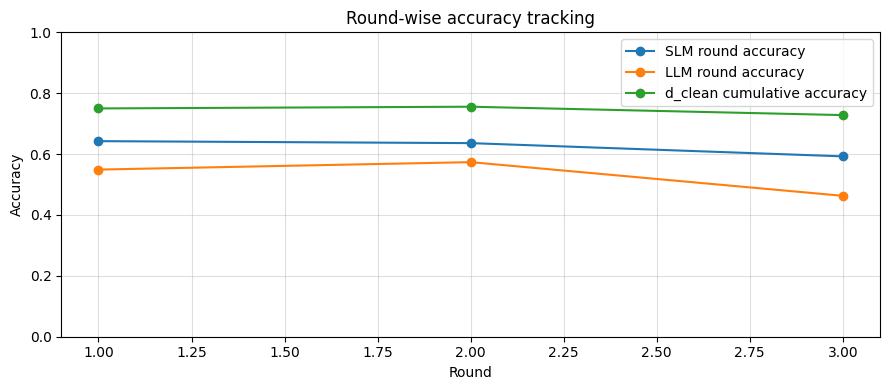

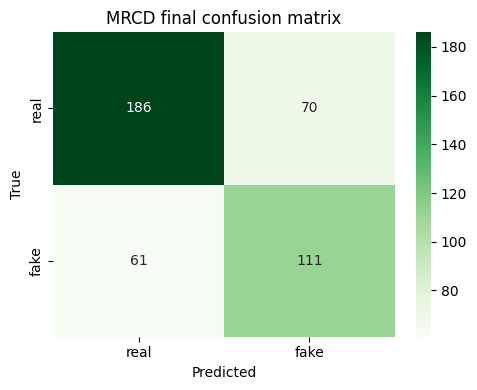

,model,accuracy,precision,recall,f1
0,SLM_only,0.642523,0.550802,0.598837,0.573816
1,MRCD,0.693925,0.613260,0.645349,0.628895


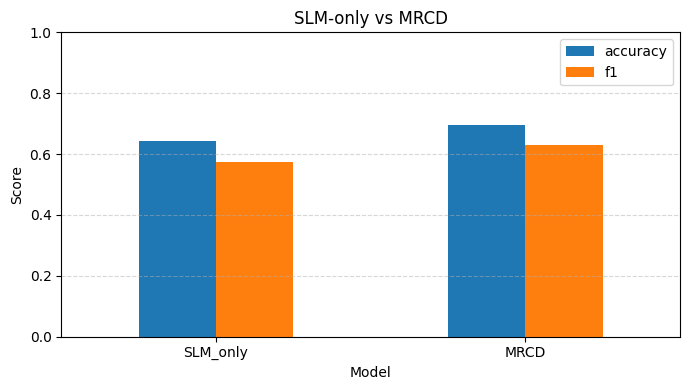

Saved comparison: /kaggle/working/log/slm_vs_mrcd_metrics.csv


In [17]:
# Round-by-round MRCD performance and final comparison
if not round_eval_rows:
    print('No round metrics collected.')
else:
    round_eval_df = pd.DataFrame(round_eval_rows)
    display(round_eval_df[['round', 'dclean_added_accuracy', 'dclean_total_accuracy', 'slm_round_accuracy', 'llm_round_accuracy', 'dclean_added_count', 'dclean_total_count', 'slm_round_count', 'llm_round_count']])

    plt.figure(figsize=(9, 4))
    plt.plot(round_eval_df['round'], round_eval_df['slm_round_accuracy'], marker='o', label='SLM round accuracy')
    plt.plot(round_eval_df['round'], round_eval_df['llm_round_accuracy'], marker='o', label='LLM round accuracy')
    plt.plot(round_eval_df['round'], round_eval_df['dclean_total_accuracy'], marker='o', label='d_clean cumulative accuracy')
    plt.title('Round-wise accuracy tracking')
    plt.xlabel('Round')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.0)
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    cm_mrcd = confusion_matrix(ground_truth, mrcd_final_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_mrcd, annot=True, fmt='d', cmap='Greens', xticklabels=['real', 'fake'], yticklabels=['real', 'fake'])
    plt.title('MRCD final confusion matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    comparison_df = pd.DataFrame([
        {'model': 'SLM_only', 'accuracy': slm_acc, 'precision': slm_prec, 'recall': slm_rec, 'f1': slm_f1},
        {'model': 'MRCD', 'accuracy': mrcd_acc, 'precision': mrcd_prec, 'recall': mrcd_rec, 'f1': mrcd_f1},
    ])
    comparison_df.to_csv(COMPARISON_CSV, index=False, encoding='utf-8')
    display(comparison_df)

    ax = comparison_df.set_index('model')[['accuracy', 'f1']].plot(kind='bar', figsize=(7, 4))
    ax.set_title('SLM-only vs MRCD')
    ax.set_xlabel('Model')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.0)
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print(f'Saved comparison: {COMPARISON_CSV}')